# RT
Load RT data and clean it step by step.

In [35]:
from pathlib import Path
from IPython.display import display
import pandas as pd

pd.set_option("display.max_colwidth", 160)

def compact_preview(frame: pd.DataFrame, *, text_col: str = "Full_Text", rows: int = 5, max_chars: int = 220) -> pd.DataFrame:
    preview = frame.copy()
    if text_col in preview.columns:
        text_series = (
            preview[text_col]
            .astype("string")
            .fillna("")
            .str.replace(r"\s+", " ", regex=True)
            .str.strip()
        )
        preview[text_col] = text_series.str.slice(0, max_chars).where(
            text_series.str.len() <= max_chars,
            text_series.str.slice(0, max_chars) + "...",
        )
    return preview.head(rows)

def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, cwd.parent):
        if (candidate / "data" / "raw" / "Alternative Medien").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root containing data/raw/Alternative Medien")

PROJECT_ROOT = resolve_project_root()
BASE_DIR = PROJECT_ROOT / "data" / "raw" / "Alternative Medien"

rt_file = BASE_DIR / "RT_de.xlsx"
df = pd.read_excel(rt_file)
df["source"] = "RT_de"
df["source_file"] = rt_file.name

# Define df_clean immediately so later cells run top-to-bottom without NameError.
df_clean = df.copy()

print(f"Loaded {len(df)} rows from {rt_file}")
display(compact_preview(df_clean, text_col="Full_Text"))


Loaded 12390 rows from /Users/MattisHaumann/Dev/Thesis/data/raw/Alternative Medien/RT_de.xlsx


,Date,Category,Title,Summary,Text,URL,Full_Text,source,source_file
0,2026-01-19,Hauptseite\n/\nInternational,"Trump: Dänemark kann ""russische Bedrohung"" in Grönland nicht beseitigen","Die Nordatlantikallianz habe Dänemark 20 Jahre lang gebeten, die ""russische Bedrohung"" für Grönland zu beseitigen, aber Kopenhagen habe diese Aufgabe nicht ...","Dänemark sei seit 20 Jahren nicht in der Lage, die ""russische Bedrohung"" in der Region Grönland zu beseitigen, behauptete US-Präsident Donald Trump. Auf sei...",https://freedert.online/international/267662-trump-wirft-daenemark-vor-russische/,"Trump: Dänemark kann ""russische Bedrohung"" in Grönland nicht beseitigenDie Nordatlantikallianz habe Dänemark 20 Jahre lang gebeten, die ""russische Bedrohung...",RT_de,RT_de.xlsx
1,2026-01-19,Hauptseite\n/\nInternational,Mindestens 39 Tote bei schwerem Zugunglück in Spanien,"Bei einem schweren Zugunglück nahe Córdoba entgleisten und kollidierten zwei Hochgeschwindigkeitszüge. Mindestens 39 Menschen kamen ums Leben, rund 70 wurde...","Bei einem schweren Zugunglück im Süden Spaniens verloren mindestens 39 Menschen ihr Leben. Rund 70 weitere Passagiere wurden verletzt, mehrere von ihnen sch...",https://freedert.online/europa/267660-mindestens-39-tote-bei-schwerem/,Mindestens 39 Tote bei schwerem Zugunglück in SpanienBei einem schweren Zugunglück nahe Córdoba entgleisten und kollidierten zwei Hochgeschwindigkeitszüge. ...,RT_de,RT_de.xlsx
2,2026-01-19,Hauptseite\n/\nNahost-Konflikt,Syriens Machthaber al-Scharaa verschiebt wegen Militäroperationen seinen Termin in Berlin,Der für Anfang der Woche angekündigte Besuch des syrischen Übergangspräsidenten Ahmed al-Scharaa im Berliner Kanzleramt ist seitens Damaskus abgesagt worden...,Bundeskanzler Friedrich Merz wird am morgigen Dienstag nicht den amtierenden syrischen Präsidenten Ahmed al-Scharaa im Berliner Bundeskanzleramt empfangen k...,https://freedert.online/der-nahe-osten/267652-syriens-machthaber-al-scharaa-verschiebt/,Syriens Machthaber al-Scharaa verschiebt wegen Militäroperationen seinen Termin in BerlinDer für Anfang der Woche angekündigte Besuch des syrischen Übergang...,RT_de,RT_de.xlsx
3,2026-01-19,Hauptseite\n/\nSchweiz,Davos wird zum US-Forum: Zum Auftakt steht das WEF im Zeichen Donald Trumps,"Die größte US-Delegation aller Zeiten, massive Sicherheitsvorkehrungen und konkrete Machtpolitik machen Davos zur Bühne amerikanischer Interessen. Noch vor ...","Das World Economic Forum 2026 steht unter einem offiziellen Leitsatz, doch die tatsächliche Dynamik folgt einer anderen Logik. In Davos dreht sich in diesem...",https://freedert.online/schweiz/267655-davos-wird-zum-us-forum/,"Davos wird zum US-Forum: Zum Auftakt steht das WEF im Zeichen Donald TrumpsDie größte US-Delegation aller Zeiten, massive Sicherheitsvorkehrungen und konkre...",RT_de,RT_de.xlsx
4,2026-01-19,Hauptseite\n/\nInternational,Welch erbärmliche und prinzipienlose Kreaturen: Warum die Europäer nun Schutz bei Russland suchen,"Europa hat Russlands Rolle verkannt und zahlt nun den Preis, während Washington das Völkerrecht und die UNO offen entwertet. Der geplante ""Friedensrat"" der ...","Von Kirill Strelnikow\n\nDie Europäer waren seinerzeit nicht in der Lage zu verstehen und zu akzeptieren, dass die militärische Sonderoperation Russlands in...",https://freedert.online/meinung/267625-welch-erbaermliche-und-prinzipienlose-kreaturen/,Welch erbärmliche und prinzipienlose Kreaturen: Warum die Europäer nun Schutz bei Russland suchenEuropa hat Russlands Rolle verkannt und zahlt nun den Preis...,RT_de,RT_de.xlsx


In [36]:
# compute and display missing values per column for the cleaned dataframe
missing = df_clean.isna().sum().rename("missing_count").to_frame()
missing["missing_pct"] = (missing["missing_count"] / len(df_clean)) * 100
missing = missing.sort_values("missing_count", ascending=False)
missing

,missing_count,missing_pct
Text,33,0.266344
Summary,14,0.112994
Date,0,0.000000
Category,0,0.000000
Title,0,0.000000
URL,0,0.000000
Full_Text,0,0.000000
source,0,0.000000
source_file,0,0.000000


In [37]:
# filter timeframe Aug 2025 through Jan 2026 (inclusive)
start, end = "2025-08-01", "2026-01-31"
dates = pd.to_datetime(df_clean["Date"], errors="coerce")
mask = (dates >= start) & (dates <= end)

df_aug2025_jan2026 = df_clean.loc[mask].copy()
df_aug2025_jan2026["Date"] = pd.to_datetime(df_aug2025_jan2026["Date"])

print(f"Rows in selected period: {len(df_aug2025_jan2026)}")
display(compact_preview(df_aug2025_jan2026.sort_values("Date"), text_col="Full_Text"))


Rows in selected period: 4570


,Date,Category,Title,Summary,Text,URL,Full_Text,source,source_file
4569,2025-08-01,Hauptseite\n/\nDeutschland,Klimaterrorismus aus Düsseldorf: Wieder Bahnstrecke lahm gelegt,"Tausende Fluggäste mussten darunter leiden, dass die Bahnanbindung des Düsseldorfer Flughafens blockiert wurde. Auslöser? Ein Anschlag auf Signalkabel der B...","Schon das Ziel des Brandanschlags auf Kabel der Deutschen Bahn deutet an, in welchen Kreisen die Verdächtigen zu suchen wären – zwischen den Bahnhöfen Duisb...",https://freedert.online/inland/252167-klimaterrorismus-aus-duesseldorf-legt-bahnstrecke/,"Klimaterrorismus aus Düsseldorf: Wieder Bahnstrecke lahm gelegtTausende Fluggäste mussten darunter leiden, dass die Bahnanbindung des Düsseldorfer Flughafen...",RT_de,RT_de.xlsx
4555,2025-08-01,Hauptseite\n/\nSchweiz,"39 Prozent Zoll: Höchster Satz trifft ""neutrale"" Schweiz hart. Linke drohen Trump mit Sanktionen",Ausgerechnet am Nationalfeiertag scheitern die Zollgespräche mit den USA. Trump verhängt 39 Prozent auf Schweizer Exporte – Europas höchster Satz. Offiziell...,"In der Schweiz ist eine Zoll-Bombe explodiert. Heute hätte der Nationalfeiertag gefeiert werden sollen. Geschäfte bleiben geschlossen, und alle genießen den...",https://freedert.online/schweiz/252151-39-prozent-zoll-fuer-schweizer/,"39 Prozent Zoll: Höchster Satz trifft ""neutrale"" Schweiz hart. Linke drohen Trump mit SanktionenAusgerechnet am Nationalfeiertag scheitern die Zollgespräche...",RT_de,RT_de.xlsx
4556,2025-08-01,Hauptseite\n/\nInternational,Reuters: Indische Raffinerien setzen nach Trumps Drohungen Käufe von russischem Öl aus,Indische staatliche Ölraffinerien haben nach Drohungen von US-Präsident Donald Trump ihre Rohölkäufe aus Russland eingestellt und ersetzen diese durch Liefe...,Die US-Nachrichtenagentur Reuters meldet das Ende der russischen Öllieferungen nach Indien. Vier große indische staatliche Ölraffinerien hätten laut anonyme...,https://freedert.online/international/252181-reuters-indische-raffinerien-setzen-nach/,Reuters: Indische Raffinerien setzen nach Trumps Drohungen Käufe von russischem Öl ausIndische staatliche Ölraffinerien haben nach Drohungen von US-Präsiden...,RT_de,RT_de.xlsx
4557,2025-08-01,Hauptseite\n/\nInternational,Russland und USA lassen ISS bis 2028 in Betrieb,Gemäß der Entscheidung der russischen und US-amerikanischen Weltraumorganisationen bleibt die Internationale Raumstation ISS bis zum Jahr 2028 in Betrieb. B...,"Russland und die USA haben den Betrieb der Internationalen Raumstation bis zum Jahr 2028 verlängert. Darauf einigten sich am Donnerstag Dmitri Bakanow, Gene...",https://freedert.online/international/252173-russland-und-usa-lassen-iss/,Russland und USA lassen ISS bis 2028 in BetriebGemäß der Entscheidung der russischen und US-amerikanischen Weltraumorganisationen bleibt die Internationale ...,RT_de,RT_de.xlsx
4558,2025-08-01,Hauptseite\n/\nInternational,"Töten, Verschleppen und Schikanen: NATO-Länder werfen Iran grenzüberschreitende Verbrechen vor","Die iranischen Geheimdienste sollen versuchen, Menschen in westlichen Ländern zu töten, zu verschleppen und zu schikanieren, sagen mehrere NATO-Länder und Ö...",Mehrere NATO-Länder haben in einer gemeinsamen Erklärung angebliche Aktivitäten der iranischen Geheimdienste verurteilt. Das am Donnerstag veröffentlichte S...,https://freedert.online/international/252192-toeten-verschleppen-und-schikanen-nato/,"Töten, Verschleppen und Schikanen: NATO-Länder werfen Iran grenzüberschreitende Verbrechen vorDie iranischen Geheimdienste sollen versuchen, Menschen in wes...",RT_de,RT_de.xlsx


In [38]:
# keep only the requested columns
_keep = ["Date", "Category", "Title", "Full_Text", "URL"]

if "df_clean" in globals():
    df_clean = df_clean.loc[:, _keep].copy()

if "df_aug2025_jan2026" in globals():
    df_aug2025_jan2026 = df_aug2025_jan2026.loc[:, _keep].copy()

if "df" in globals():
    df = df.loc[:, _keep].copy()

# show compact result
display(compact_preview(df_clean, text_col="Full_Text"))


,Date,Category,Full_Text,URL
0,2026-01-19,Hauptseite\n/\nInternational,"Trump: Dänemark kann ""russische Bedrohung"" in Grönland nicht beseitigenDie Nordatlantikallianz habe Dänemark 20 Jahre lang gebeten, die ""russische Bedrohung...",https://freedert.online/international/267662-trump-wirft-daenemark-vor-russische/
1,2026-01-19,Hauptseite\n/\nInternational,Mindestens 39 Tote bei schwerem Zugunglück in SpanienBei einem schweren Zugunglück nahe Córdoba entgleisten und kollidierten zwei Hochgeschwindigkeitszüge. ...,https://freedert.online/europa/267660-mindestens-39-tote-bei-schwerem/
2,2026-01-19,Hauptseite\n/\nNahost-Konflikt,Syriens Machthaber al-Scharaa verschiebt wegen Militäroperationen seinen Termin in BerlinDer für Anfang der Woche angekündigte Besuch des syrischen Übergang...,https://freedert.online/der-nahe-osten/267652-syriens-machthaber-al-scharaa-verschiebt/
3,2026-01-19,Hauptseite\n/\nSchweiz,"Davos wird zum US-Forum: Zum Auftakt steht das WEF im Zeichen Donald TrumpsDie größte US-Delegation aller Zeiten, massive Sicherheitsvorkehrungen und konkre...",https://freedert.online/schweiz/267655-davos-wird-zum-us-forum/
4,2026-01-19,Hauptseite\n/\nInternational,Welch erbärmliche und prinzipienlose Kreaturen: Warum die Europäer nun Schutz bei Russland suchenEuropa hat Russlands Rolle verkannt und zahlt nun den Preis...,https://freedert.online/meinung/267625-welch-erbaermliche-und-prinzipienlose-kreaturen/


In [39]:
display(compact_preview(df_clean, text_col="Full_Text", rows=3))


,Date,Category,Full_Text,URL
0,2026-01-19,Hauptseite\n/\nInternational,"Trump: Dänemark kann ""russische Bedrohung"" in Grönland nicht beseitigenDie Nordatlantikallianz habe Dänemark 20 Jahre lang gebeten, die ""russische Bedrohung...",https://freedert.online/international/267662-trump-wirft-daenemark-vor-russische/
1,2026-01-19,Hauptseite\n/\nInternational,Mindestens 39 Tote bei schwerem Zugunglück in SpanienBei einem schweren Zugunglück nahe Córdoba entgleisten und kollidierten zwei Hochgeschwindigkeitszüge. ...,https://freedert.online/europa/267660-mindestens-39-tote-bei-schwerem/
2,2026-01-19,Hauptseite\n/\nNahost-Konflikt,Syriens Machthaber al-Scharaa verschiebt wegen Militäroperationen seinen Termin in BerlinDer für Anfang der Woche angekündigte Besuch des syrischen Übergang...,https://freedert.online/der-nahe-osten/267652-syriens-machthaber-al-scharaa-verschiebt/


Removal of "Mehr zum Thema"

In [40]:
import re
def remove_mehr_zum_thema(text):
    if pd.isna(text):
        return text
    
    # Remove everything from "Mehr zum Thema" until end
    cleaned = re.sub(r"\n*\s*Mehr zum Thema.*$", "", text, flags=re.DOTALL)
    return cleaned.strip()

df_clean["Full_Text"] = df_clean["Full_Text"].apply(remove_mehr_zum_thema)

In [41]:
display(compact_preview(df_clean, text_col="Full_Text"))


,Date,Category,Full_Text,URL
0,2026-01-19,Hauptseite\n/\nInternational,"Trump: Dänemark kann ""russische Bedrohung"" in Grönland nicht beseitigenDie Nordatlantikallianz habe Dänemark 20 Jahre lang gebeten, die ""russische Bedrohung...",https://freedert.online/international/267662-trump-wirft-daenemark-vor-russische/
1,2026-01-19,Hauptseite\n/\nInternational,Mindestens 39 Tote bei schwerem Zugunglück in SpanienBei einem schweren Zugunglück nahe Córdoba entgleisten und kollidierten zwei Hochgeschwindigkeitszüge. ...,https://freedert.online/europa/267660-mindestens-39-tote-bei-schwerem/
2,2026-01-19,Hauptseite\n/\nNahost-Konflikt,Syriens Machthaber al-Scharaa verschiebt wegen Militäroperationen seinen Termin in BerlinDer für Anfang der Woche angekündigte Besuch des syrischen Übergang...,https://freedert.online/der-nahe-osten/267652-syriens-machthaber-al-scharaa-verschiebt/
3,2026-01-19,Hauptseite\n/\nSchweiz,"Davos wird zum US-Forum: Zum Auftakt steht das WEF im Zeichen Donald TrumpsDie größte US-Delegation aller Zeiten, massive Sicherheitsvorkehrungen und konkre...",https://freedert.online/schweiz/267655-davos-wird-zum-us-forum/
4,2026-01-19,Hauptseite\n/\nInternational,Welch erbärmliche und prinzipienlose Kreaturen: Warum die Europäer nun Schutz bei Russland suchenEuropa hat Russlands Rolle verkannt und zahlt nun den Preis...,https://freedert.online/meinung/267625-welch-erbaermliche-und-prinzipienlose-kreaturen/


In [42]:
!pip install seaborn

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 6)

eda_df = df_clean.copy() if "df_clean" in globals() else df.copy()
eda_df["Date"] = pd.to_datetime(eda_df["Date"], errors="coerce")

text_col = "Full_Text" if "Full_Text" in eda_df.columns else "Text"
eda_df[text_col] = eda_df[text_col].astype("string")
eda_df = eda_df.dropna(subset=["Date", text_col]).copy()

print(f"Rows used for EDA: {len(eda_df):,}")

Rows used for EDA: 12,390


In [44]:
eda_df["article_length_words"] = eda_df[text_col].str.split().str.len()
eda_df["article_length_chars"] = eda_df[text_col].str.len()

eda_df["article_length_words"].describe(
    percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
).round(1)

count    12390.0
mean       615.5
std        415.4
min          7.0
10%        281.0
25%        347.0
50%        456.0
75%        738.0
90%       1233.1
95%       1480.0
99%       1998.0
max       4689.0
Name: article_length_words, dtype: float64

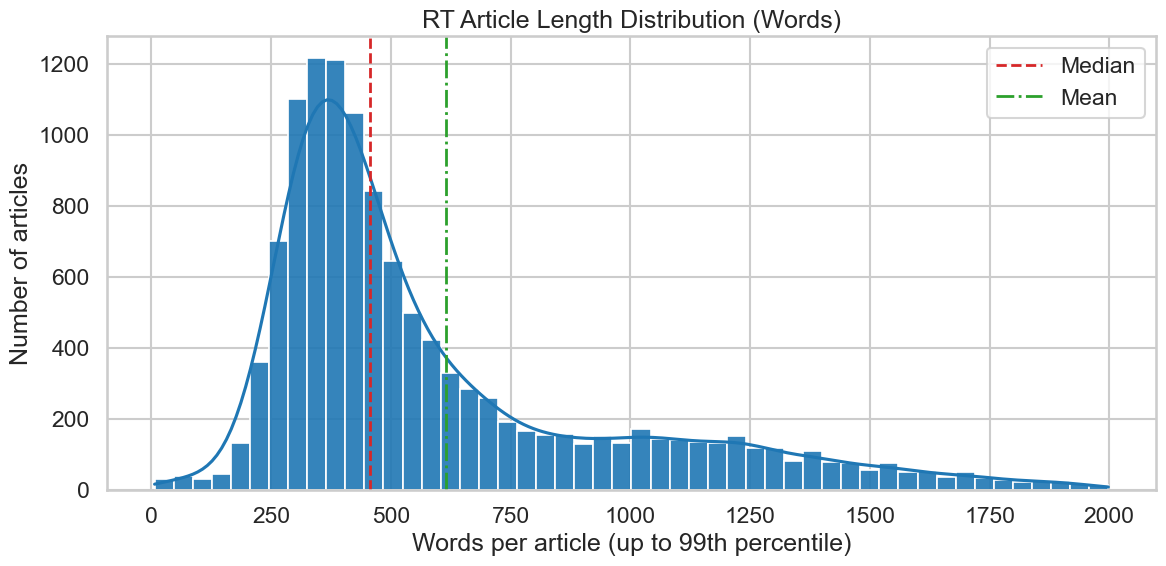

In [45]:
q99 = eda_df["article_length_words"].quantile(0.99)
length_plot = eda_df[eda_df["article_length_words"] <= q99]

fig, ax = plt.subplots(figsize=(12, 6))
sns.histplot(
    length_plot["article_length_words"],
    bins=50,
    kde=True,
    color="#1f77b4",
    edgecolor="white",
    alpha=0.9,
    ax=ax,
)

ax.axvline(eda_df["article_length_words"].median(), color="#d62728", linestyle="--", linewidth=2, label="Median")
ax.axvline(eda_df["article_length_words"].mean(), color="#2ca02c", linestyle="-.", linewidth=2, label="Mean")
ax.set_title("RT Article Length Distribution (Words)")
ax.set_xlabel("Words per article (up to 99th percentile)")
ax.set_ylabel("Number of articles")
ax.legend()
plt.tight_layout()
plt.show()

In [46]:
daily_counts = (
    eda_df.set_index("Date")
    .resample("D")
    .size()
    .rename("articles")
    .reset_index()
)
daily_counts["rolling_7d"] = daily_counts["articles"].rolling(7, min_periods=1).mean()

daily_counts.head()

,Date,articles,rolling_7d
0,2024-11-14,24,24.0
1,2024-11-15,24,24.0
2,2024-11-16,24,24.0
3,2024-11-17,20,23.0
4,2024-11-18,30,24.4


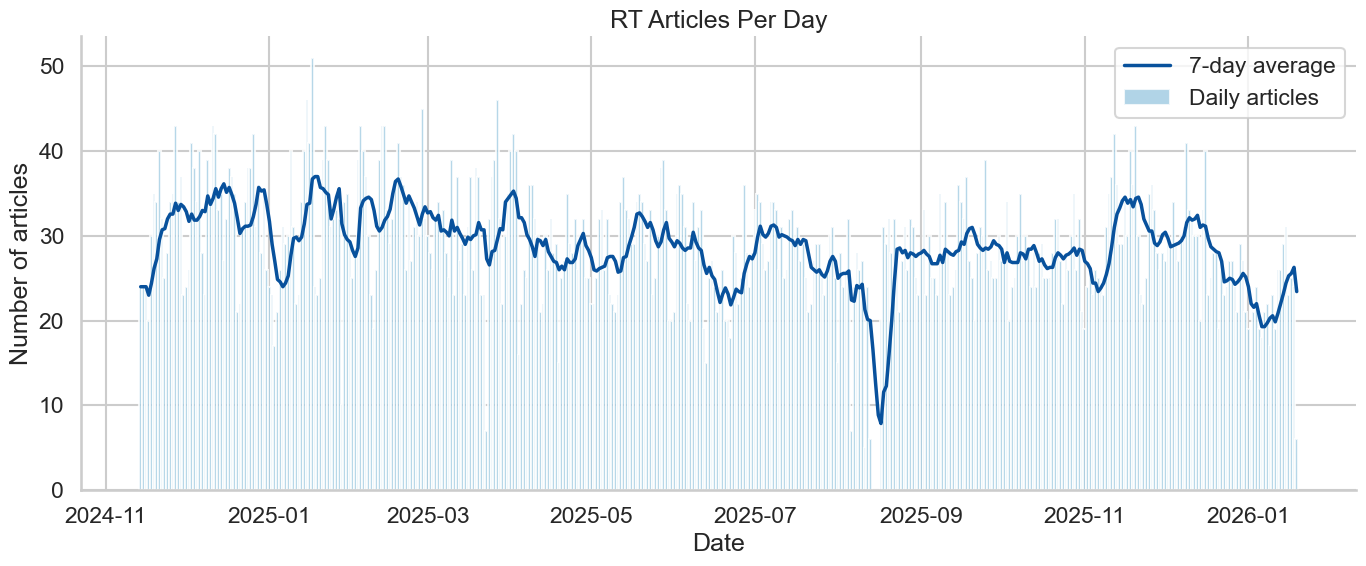

In [47]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(
    daily_counts["Date"],
    daily_counts["articles"],
    color="#9ecae1",
    alpha=0.8,
    width=1.0,
    label="Daily articles",
)
ax.plot(
    daily_counts["Date"],
    daily_counts["rolling_7d"],
    color="#08519c",
    linewidth=2.5,
    label="7-day average",
)

ax.set_title("RT Articles Per Day")
ax.set_xlabel("Date")
ax.set_ylabel("Number of articles")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=True)
plt.tight_layout()
plt.show()

## BERTopic


In [48]:
from pathlib import Path
import sys

project_root = Path.cwd()
if project_root.name == "data preprocessing":
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

In [49]:
from BERTopic.bertopic_config import BERTopicConfig, title_config
from BERTopic.bertopic_pipeline import run_bertopic_pipeline


In [50]:
display(compact_preview(df_clean[["Full_Text", "Title", "URL"]], text_col="Full_Text"))


,Full_Text,URL
0,"Trump: Dänemark kann ""russische Bedrohung"" in Grönland nicht beseitigenDie Nordatlantikallianz habe Dänemark 20 Jahre lang gebeten, die ""russische Bedrohung...",https://freedert.online/international/267662-trump-wirft-daenemark-vor-russische/
1,Mindestens 39 Tote bei schwerem Zugunglück in SpanienBei einem schweren Zugunglück nahe Córdoba entgleisten und kollidierten zwei Hochgeschwindigkeitszüge. ...,https://freedert.online/europa/267660-mindestens-39-tote-bei-schwerem/
2,Syriens Machthaber al-Scharaa verschiebt wegen Militäroperationen seinen Termin in BerlinDer für Anfang der Woche angekündigte Besuch des syrischen Übergang...,https://freedert.online/der-nahe-osten/267652-syriens-machthaber-al-scharaa-verschiebt/
3,"Davos wird zum US-Forum: Zum Auftakt steht das WEF im Zeichen Donald TrumpsDie größte US-Delegation aller Zeiten, massive Sicherheitsvorkehrungen und konkre...",https://freedert.online/schweiz/267655-davos-wird-zum-us-forum/
4,Welch erbärmliche und prinzipienlose Kreaturen: Warum die Europäer nun Schutz bei Russland suchenEuropa hat Russlands Rolle verkannt und zahlt nun den Preis...,https://freedert.online/meinung/267625-welch-erbaermliche-und-prinzipienlose-kreaturen/


In [51]:
# 1) BERTopic on full article text
result_full_text = run_bertopic_pipeline(
    df=df_clean,
    text_col="Full_Text",
    config=BERTopicConfig(),
    id_col="URL",
    source_name="RT_de",
)

# 2) BERTopic on titles only
result_title = run_bertopic_pipeline(
    df=df_clean,
    text_col="Title",
    config=title_config(),
    id_col="URL",
    source_name="RT_de",
)

# Keep downstream notebook cells unchanged (they use `result`)
result = result_full_text


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-03-06 16:57:40,766 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/388 [00:00<?, ?it/s]

2026-03-06 16:58:36,270 - BERTopic - Embedding - Completed ✓
2026-03-06 16:58:36,271 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-06 16:58:42,792 - BERTopic - Dimensionality - Completed ✓
2026-03-06 16:58:42,793 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-06 16:58:43,013 - BERTopic - Cluster - Completed ✓
2026-03-06 16:58:43,017 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-06 16:58:48,712 - BERTopic - Representation - Completed ✓


In [52]:
topic_info = result["topic_info"]
topic_info.head(20)


,Topic,Count,Name,Representation,Representative_Docs
0,-1,4723,-1_selenskij_merz_polen_afd,"[selenskij, merz, polen, afd, russen, für ukraine, biden, raketen, macron, ukrainer]",[Die europäischen Eliten sehen in der Unterstützung der Ukraine ihre RettungDie Bereitstellung von mehr Geld und Waffen für die Ukraine und die Entsendung v...
1,0,1079,0_israel_syrien_al_gaza,"[israel, syrien, al, gaza, israelischen, hamas, israelische, gazastreifen, israels, netanjahu]","[Völkermord verhindert? – Israel löst das ""Syrien-Problem"" auf radikale WeiseIsrael feiert einen weiteren Sieg: Es nahm die neue Führung in Syrien ins Visie..."
2,1,430,1_afd_spd_bsw_cdu,"[afd, spd, bsw, cdu, bundestag, grünen, csu, bundestagswahl, wagenknecht, merz]",[Ipsos-Umfrage: AfD erstmalig mit 25 Prozent vor UnionsparteienDas Marktforschungsunternehmen präsentiert am Tag der erwarteten Endergebnisse der Sondierung...
3,2,385,2_österreich_flüchtlinge_milliarden euro_ukrainer,"[österreich, flüchtlinge, milliarden euro, ukrainer, bundesregierung, industrie, anstieg, bürgergeld, rückgang, wien]","[Stromsteuerbremse nur fürs Kapital – und Propaganda fürs VolkDie GroKo hat entschieden: Die Stromsteuer sinkt – aber nur fürs Kapital. Die ""kleinen Leute"" ..."
4,3,326,3_sowjetischen_russen_sowjetunion_gedenken,"[sowjetischen, russen, sowjetunion, gedenken, befreiung, sowjetische, 1945, film, propaganda, faschismus]","[Wer waren die Befreier von Auschwitz?Je länger die Ereignisse des Zweiten Weltkrieges zurückliegen, desto wichtiger wird es, die Tatsache der sowjetischen ..."
5,4,283,4_polizei_täter_verletzt_magdeburg,"[polizei, täter, verletzt, magdeburg, jähriger, jährige, verletzte, messer, ermittlungen, jährigen]","[""Sehr ungewöhnliches Täterprofil"" – Neues zum Magdeburg-AttentatDer Fahrer eines Pkws steuert auf dem Magdeburger Weihnachtsmarkt in eine Menschenmenge. Du..."
6,5,257,5_venezuela_maduro_venezuelas_venezolanischen,"[venezuela, maduro, venezuelas, venezolanischen, karibik, caracas, nicolás, nicolás maduro, kuba, drogen]","[Trump kündigt Bodeneinsätze gegen Drogenhandel an: ""Die Rede ist nicht nur von Venezuela""Donald Trump hat sich die Drogenbekämpfung auf die Fahne geschrieb..."
7,6,210,6_epstein_cia_kennedy_fbi,"[epstein, cia, kennedy, fbi, usaid, jeffrey, akten, hegseth, demokraten, pentagon]","[Trump verstört Anhänger: Nur ""dumme Leute"" interessieren sich für die Epstein-AktenDer US-Präsident hat seine Anhänger scharf kritisiert, die von der jüngs..."
8,7,193,7_lawrow_witkoff_putin trump_russischen präsidenten,"[lawrow, witkoff, putin trump, russischen präsidenten, kreml, telefonat, selenskij, alaska, sergei, uschakow]",[Kreml-Berater: Putin und Trump einigten sich nicht auf Gipfeltreffen mit SelenskijBei ihrem Gipfel in Alaska haben US-Präsident Donald Trump und sein russi...
9,8,185,8_kursk_sumy_podoljaka_ukrainischen streitkräfte,"[kursk, sumy, podoljaka, ukrainischen streitkräfte, befreiung, pokrowsk, frontabschnitt, konstantinowka, gebiet kursk, russischen streitkräfte]",[Fronteinbruch für Kiew? Übersicht der GefechtslageAuch am Ende des Frühlings bleiben die Kämpfe an den Fronten des Ukraine-Krieges intensiv. Russlands Stre...


In [53]:
doc_info = result["doc_info"]
doc_info.head()

,original_index,document_id,source_name,Document,Topic,Name,Representation,Representative_Docs,Top_n_words,Probability,Representative_document
0,0,https://freedert.online/international/267662-trump-wirft-daenemark-vor-russische/,RT_de,"Trump: Dänemark kann ""russische Bedrohung"" in Grönland nicht beseitigenDie Nordatlantikallianz habe Dänemark 20 Jahre lang gebeten, die ""russische Bedrohung...",31,31_grönland_dänemark_insel_grönlands,"[grönland, dänemark, insel, grönlands, dänische, arktis, dänemarks, dänischen, frederiksen, kopenhagen]",[Nach Drohungen von Trump: Grönland kommt USA entgegenGrönland öffnet sich für eine Zusammenarbeit mit den USA zur Erschließung von Rohstoffen. Während die ...,grönland - dänemark - insel - grönlands - dänische - arktis - dänemarks - dänischen - frederiksen - kopenhagen,1.000000,False
1,1,https://freedert.online/europa/267660-mindestens-39-tote-bei-schwerem/,RT_de,Mindestens 39 Tote bei schwerem Zugunglück in SpanienBei einem schweren Zugunglück nahe Córdoba entgleisten und kollidierten zwei Hochgeschwindigkeitszüge. ...,4,4_polizei_täter_verletzt_magdeburg,"[polizei, täter, verletzt, magdeburg, jähriger, jährige, verletzte, messer, ermittlungen, jährigen]","[""Sehr ungewöhnliches Täterprofil"" – Neues zum Magdeburg-AttentatDer Fahrer eines Pkws steuert auf dem Magdeburger Weihnachtsmarkt in eine Menschenmenge. Du...",polizei - täter - verletzt - magdeburg - jähriger - jährige - verletzte - messer - ermittlungen - jährigen,0.635394,False
2,2,https://freedert.online/der-nahe-osten/267652-syriens-machthaber-al-scharaa-verschiebt/,RT_de,Syriens Machthaber al-Scharaa verschiebt wegen Militäroperationen seinen Termin in BerlinDer für Anfang der Woche angekündigte Besuch des syrischen Übergang...,0,0_israel_syrien_al_gaza,"[israel, syrien, al, gaza, israelischen, hamas, israelische, gazastreifen, israels, netanjahu]","[Völkermord verhindert? – Israel löst das ""Syrien-Problem"" auf radikale WeiseIsrael feiert einen weiteren Sieg: Es nahm die neue Führung in Syrien ins Visie...",israel - syrien - al - gaza - israelischen - hamas - israelische - gazastreifen - israels - netanjahu,1.000000,False
3,3,https://freedert.online/schweiz/267655-davos-wird-zum-us-forum/,RT_de,"Davos wird zum US-Forum: Zum Auftakt steht das WEF im Zeichen Donald TrumpsDie größte US-Delegation aller Zeiten, massive Sicherheitsvorkehrungen und konkre...",-1,-1_selenskij_merz_polen_afd,"[selenskij, merz, polen, afd, russen, für ukraine, biden, raketen, macron, ukrainer]",[Die europäischen Eliten sehen in der Unterstützung der Ukraine ihre RettungDie Bereitstellung von mehr Geld und Waffen für die Ukraine und die Entsendung v...,selenskij - merz - polen - afd - russen - für ukraine - biden - raketen - macron - ukrainer,0.000000,False
4,4,https://freedert.online/meinung/267625-welch-erbaermliche-und-prinzipienlose-kreaturen/,RT_de,Welch erbärmliche und prinzipienlose Kreaturen: Warum die Europäer nun Schutz bei Russland suchenEuropa hat Russlands Rolle verkannt und zahlt nun den Preis...,-1,-1_selenskij_merz_polen_afd,"[selenskij, merz, polen, afd, russen, für ukraine, biden, raketen, macron, ukrainer]",[Die europäischen Eliten sehen in der Unterstützung der Ukraine ihre RettungDie Bereitstellung von mehr Geld und Waffen für die Ukraine und die Entsendung v...,selenskij - merz - polen - afd - russen - für ukraine - biden - raketen - macron - ukrainer,0.000000,False


In [54]:
rt_topics = df_clean.reset_index().merge(
    doc_info[["original_index", "Topic", "Name", "Probability"]],
    left_on="index",
    right_on="original_index",
    how="left",
)

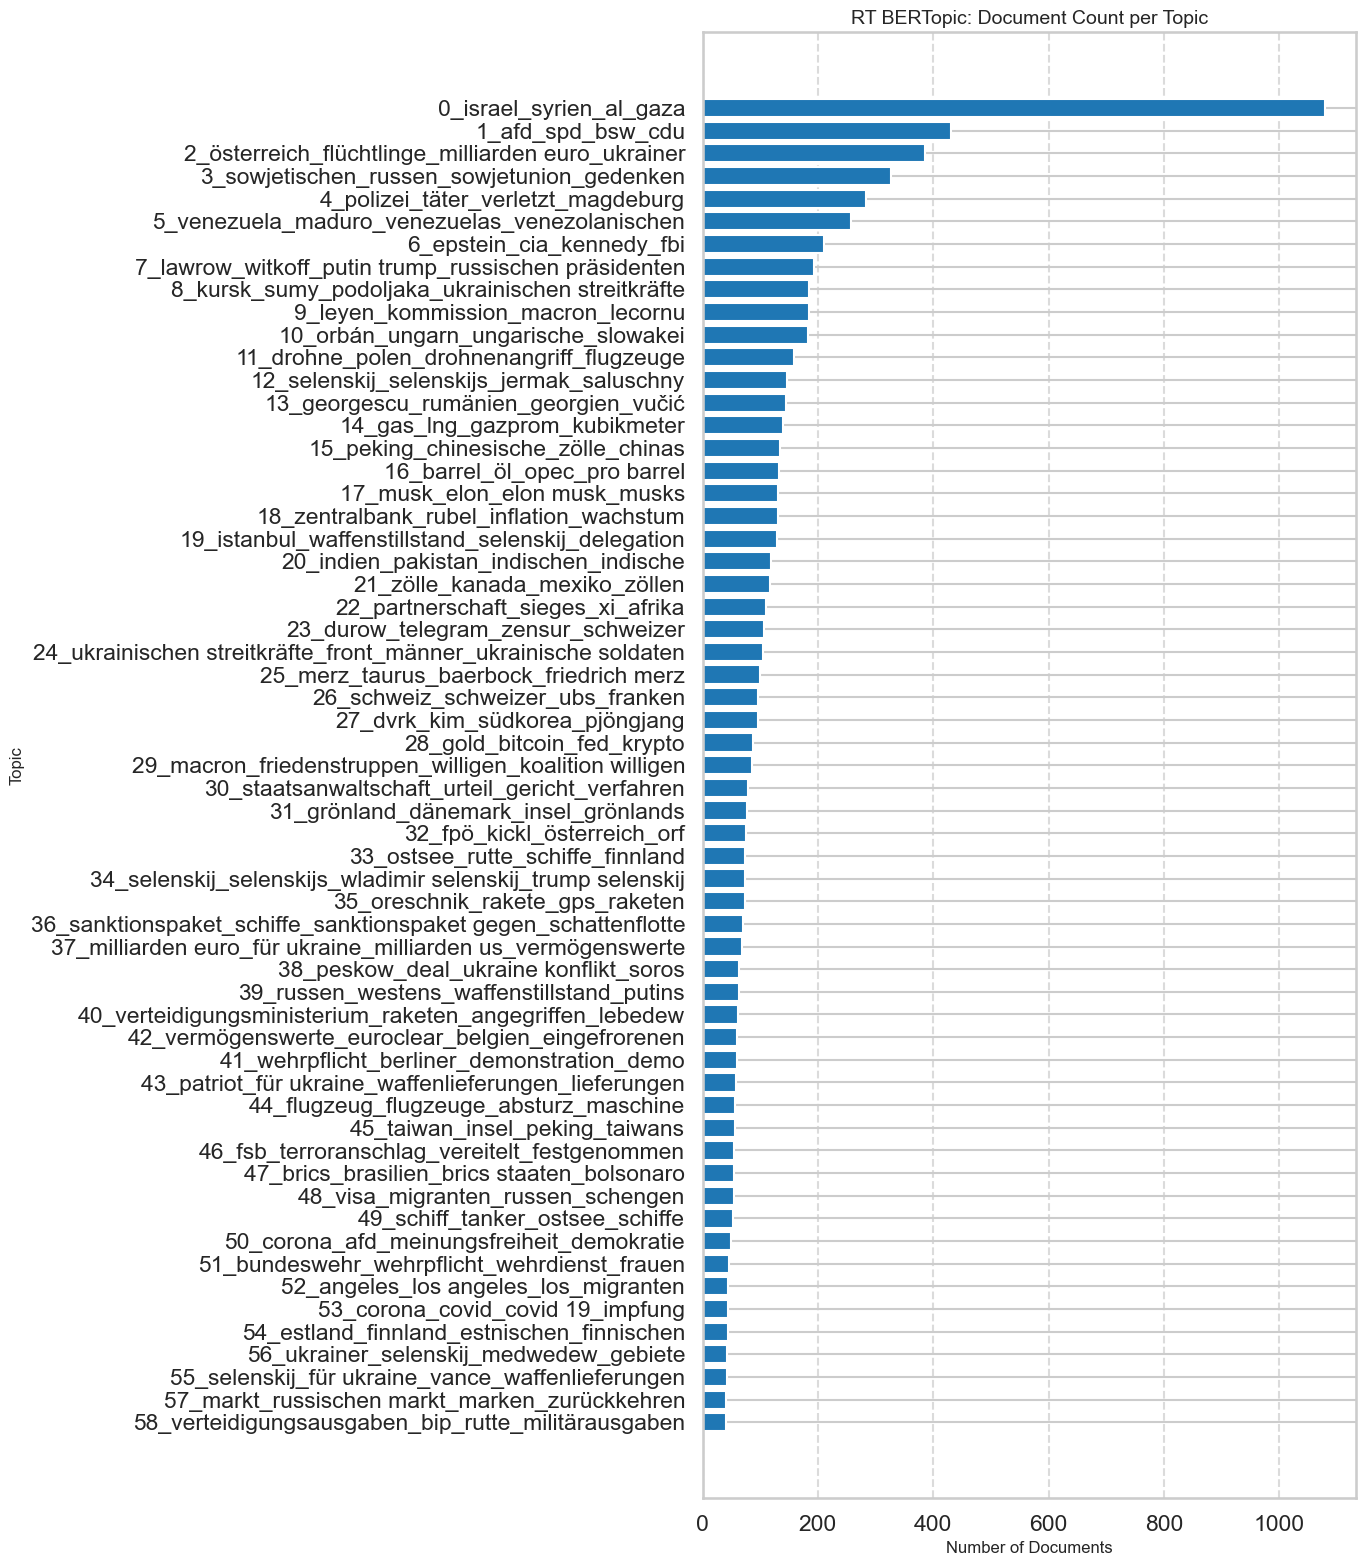

In [55]:
fig, ax = plt.subplots(figsize=(14, 16))

# Exclude topic -1 (outliers) for cleaner visualization
topic_counts = topic_info[topic_info['Topic'] != -1].copy()
topic_counts = topic_counts.sort_values('Count', ascending=True)

ax.barh(topic_counts['Name'], topic_counts['Count'], color='#1f77b4', edgecolor='white')

ax.set_xlabel('Number of Documents', fontsize=12)
ax.set_ylabel('Topic', fontsize=12)
ax.set_title('RT BERTopic: Document Count per Topic', fontsize=14)
ax.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

6it [00:07,  1.24s/it]


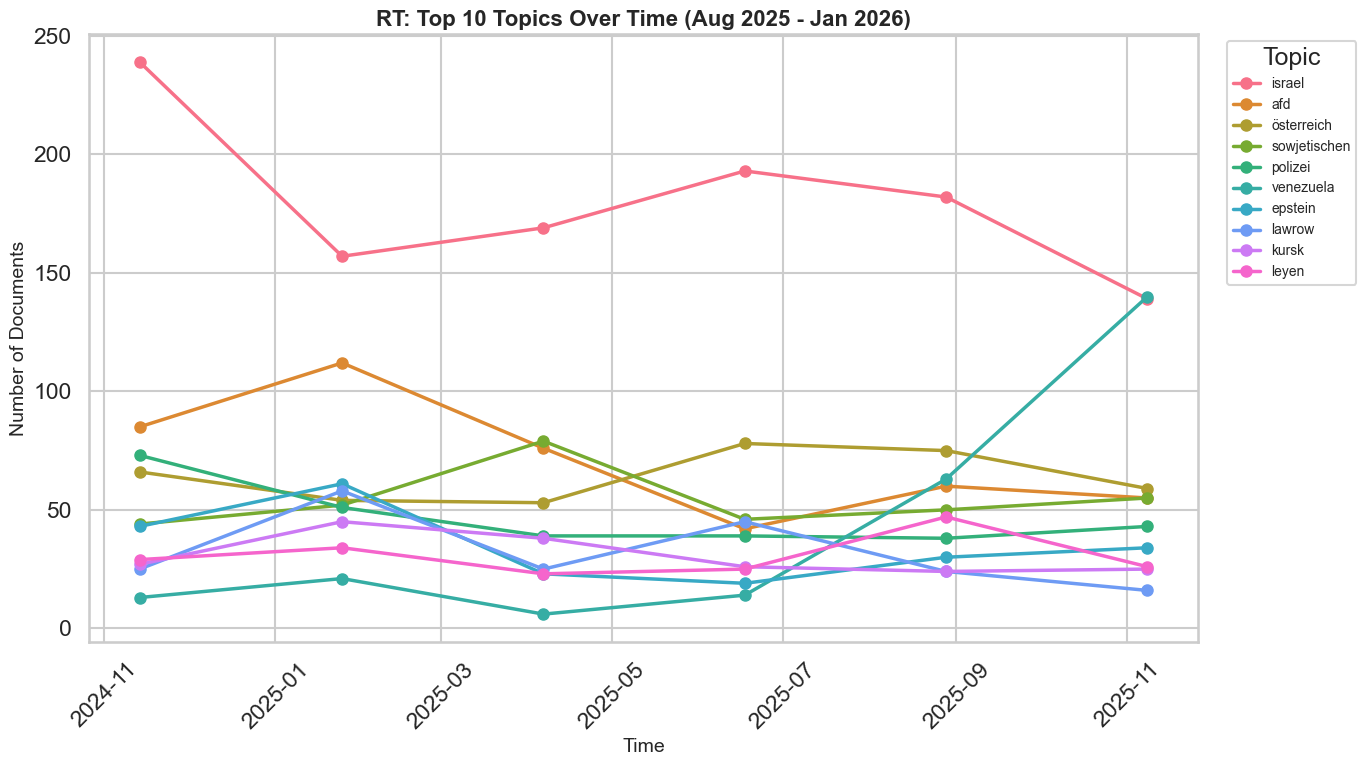

In [56]:
# Prepare data for topics over time
prepared_dates = pd.to_datetime(result["prepared_documents"]["Date"], errors="coerce")
valid_time_mask = prepared_dates.notna().tolist()
docs_for_time = [doc for doc, ok in zip(result["docs"], valid_time_mask) if ok]
timestamps_for_time = [ts for ts in prepared_dates.tolist() if pd.notna(ts)]

topics_over_time = result["topic_model"].topics_over_time(
    docs_for_time,
    timestamps_for_time,
    nr_bins=6
)

# Get top 10 topics by count (excluding -1)
top_10_topics = topic_info[topic_info['Topic'] != -1].nlargest(10, 'Count')['Topic'].tolist()

# Filter for top 10 topics
topics_over_time_filtered = topics_over_time[topics_over_time['Topic'].isin(top_10_topics)]

# Create topic name mapping
topic_name_map = dict(zip(topic_info['Topic'], topic_info['Name']))

# Plot
fig, ax = plt.subplots(figsize=(14, 8))
sns.set_theme(style="whitegrid", context="talk")

palette = sns.color_palette("husl", n_colors=10)

for i, topic in enumerate(top_10_topics):
    topic_data = topics_over_time_filtered[topics_over_time_filtered['Topic'] == topic]
    label = topic_name_map.get(topic, f"Topic {topic}")
    # Shorten label for legend
    short_label = label.split('_')[1] if '_' in label else label
    ax.plot(topic_data['Timestamp'], topic_data['Frequency'], 
            marker='o', linewidth=2.5, markersize=8, 
            color=palette[i], label=short_label)

ax.set_xlabel('Time', fontsize=14)
ax.set_ylabel('Number of Documents', fontsize=14)
ax.set_title('RT: Top 10 Topics Over Time (Aug 2025 - Jan 2026)', fontsize=16, fontweight='bold')
ax.legend(title='Topic', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [57]:
# Final BERTopic comparison table: all topics + representative words
from IPython.display import display

topics_comparison_df = topic_info[["Topic", "Name", "Count"]].copy()

def _representative_words_for_topic(topic_id: int) -> str:
    terms = result["topic_model"].get_topic(int(topic_id)) or []
    return ", ".join(word for word, _ in terms)

topics_comparison_df["Representative_Words"] = topics_comparison_df["Topic"].apply(_representative_words_for_topic)
topics_comparison_df = topics_comparison_df.sort_values("Topic").reset_index(drop=True)

with pd.option_context("display.max_colwidth", None, "display.width", 220):
    display(topics_comparison_df)


,Topic,Name,Count,Representative_Words
0,-1,-1_selenskij_merz_polen_afd,4723,"selenskij, merz, polen, afd, russen, für ukraine, biden, raketen, macron, ukrainer"
1,0,0_israel_syrien_al_gaza,1079,"israel, syrien, al, gaza, israelischen, hamas, israelische, gazastreifen, israels, netanjahu"
2,1,1_afd_spd_bsw_cdu,430,"afd, spd, bsw, cdu, bundestag, grünen, csu, bundestagswahl, wagenknecht, merz"
3,2,2_österreich_flüchtlinge_milliarden euro_ukrainer,385,"österreich, flüchtlinge, milliarden euro, ukrainer, bundesregierung, industrie, anstieg, bürgergeld, rückgang, wien"
4,3,3_sowjetischen_russen_sowjetunion_gedenken,326,"sowjetischen, russen, sowjetunion, gedenken, befreiung, sowjetische, 1945, film, propaganda, faschismus"
5,4,4_polizei_täter_verletzt_magdeburg,283,"polizei, täter, verletzt, magdeburg, jähriger, jährige, verletzte, messer, ermittlungen, jährigen"
6,5,5_venezuela_maduro_venezuelas_venezolanischen,257,"venezuela, maduro, venezuelas, venezolanischen, karibik, caracas, nicolás, nicolás maduro, kuba, drogen"
7,6,6_epstein_cia_kennedy_fbi,210,"epstein, cia, kennedy, fbi, usaid, jeffrey, akten, hegseth, demokraten, pentagon"
8,7,7_lawrow_witkoff_putin trump_russischen präsidenten,193,"lawrow, witkoff, putin trump, russischen präsidenten, kreml, telefonat, selenskij, alaska, sergei, uschakow"
9,8,8_kursk_sumy_podoljaka_ukrainischen streitkräfte,185,"kursk, sumy, podoljaka, ukrainischen streitkräfte, befreiung, pokrowsk, frontabschnitt, konstantinowka, gebiet kursk, russischen streitkräfte"


In [ ]:
# BERTopic v2 run: full text first, then title-only
from BERTopic.bertopic_pipelinev2 import (
    BERTopicV2Config,
    BERTopicV2ConfigTitle,
    run_bertopic_pipeline,
)

result_full_text_v2 = run_bertopic_pipeline(
    df=df_clean,
    text_col="Full_Text",
    config=BERTopicV2Config(),
    id_col="URL",
    source_name="RT_de",
)

result_title_v2 = run_bertopic_pipeline(
    df=df_clean,
    text_col="Title",
    config=BERTopicV2ConfigTitle(),
    id_col="URL",
    source_name="RT_de",
)

print(
    f"v2 full-text docs: {len(result_full_text_v2['docs']):,} | "
    f"v2 title docs: {len(result_title_v2['docs']):,}"
)

